CENG 467 – Q1: Representation Learning in Text Classification  
Dataset : IMDb Sentiment Analysis

Models  : TF-IDF + LR  |  BiLSTM  |  DistilBERT  

In [1]:
# !pip install -q datasets transformers torch scikit-learn matplotlib seaborn

In [1]:
import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.pipeline import Pipeline

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# GPU kotasını korumak için IMDb'den küçük bir slice kullanıyoruz.
# Tüm veri seti için TRAIN_SIZE=25000, TEST_SIZE=25000 yap.
TRAIN_SIZE = 5000
VAL_SIZE   = 1000
TEST_SIZE  = 2000

Device: cuda


In [2]:
print("IMDb veri seti yükleniyor...")
raw = load_dataset("imdb")

# Shuffle + slice
train_data = raw["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
test_full  = raw["test"].shuffle(seed=SEED)
val_data   = test_full.select(range(VAL_SIZE))
test_data  = test_full.select(range(VAL_SIZE, VAL_SIZE + TEST_SIZE))

print(f"Train : {len(train_data)} örnekler")
print(f"Val   : {len(val_data)} örnekler")
print(f"Test  : {len(test_data)} örnekler")

# Etiket dağılımı
train_labels = train_data["label"]
pos = sum(train_labels)
neg = len(train_labels) - pos
print(f"\nTrain — Pozitif: {pos} | Negatif: {neg}")

# Ham metin ve etiket listelerine çevir
X_train = train_data["text"]
y_train = train_data["label"]
X_val   = val_data["text"]
y_val   = val_data["label"]
X_test  = test_data["text"]
y_test  = test_data["label"]


IMDb veri seti yükleniyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train : 5000 örnekler
Val   : 1000 örnekler
Test  : 2000 örnekler

Train — Pozitif: 2506 | Negatif: 2494


In [3]:
def evaluate(y_true, y_pred, model_name="Model"):
    """Accuracy ve Macro-F1 hesapla, classification report yazdır."""
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Macro-F1  : {f1:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred,
                                target_names=["Negative", "Positive"]))
    return acc, f1


def plot_confusion_matrix(y_true, y_pred, model_name, save_path=None):
    """Confusion matrix çiz ve kaydet."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Neg", "Pos"],
                yticklabels=["Neg", "Pos"])
    plt.title(f"Confusion Matrix – {model_name}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Kaydedildi: {save_path}")
    plt.show()


def show_misclassified(X, y_true, y_pred, n=5, model_name="Model"):
    """İlk n yanlış sınıflandırılmış örneği göster."""
    labels = ["Negative", "Positive"]
    print(f"\n{'='*60}")
    print(f"  {model_name} — Yanlış Sınıflandırılan {n} Örnek")
    print(f"{'='*60}")
    count = 0
    for i, (true, pred) in enumerate(zip(y_true, y_pred)):
        if true != pred:
            text_preview = X[i][:200].replace("\n", " ")
            print(f"\n[{count+1}] True: {labels[true]} | Pred: {labels[pred]}")
            print(f"    Text: {text_preview}...")
            count += 1
            if count >= n:
                break

In [4]:
import os
os.makedirs("figures", exist_ok=True)


████████████████████████████████████████████████████████████
  MODEL 1: TF-IDF + Logistic Regression
████████████████████████████████████████████████████████████
Unigram TF-IDF eğitiliyor...

  TF-IDF Unigram + LR (Val)
  Accuracy  : 0.8470
  Macro-F1  : 0.8470
              precision    recall  f1-score   support

    Negative       0.88      0.82      0.85       512
    Positive       0.82      0.88      0.85       488

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000


Bigram TF-IDF eğitiliyor...

  TF-IDF Bigram + LR (Val)
  Accuracy  : 0.8600
  Macro-F1  : 0.8600
              precision    recall  f1-score   support

    Negative       0.88      0.84      0.86       512
    Positive       0.84      0.88      0.86       488

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      

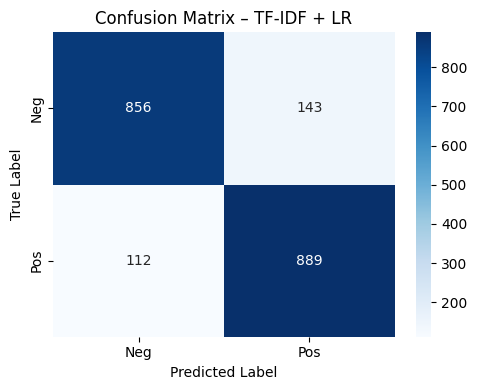


  TF-IDF + LR — Yanlış Sınıflandırılan 5 Örnek

[1] True: Positive | Pred: Negative
    Text: I saw "Night of the Demons 2" first before I saw "Night of the Demons". Unfortunately, my old Blockbuster thought it was a good idea to have the sequel, but no first one. Looney, huh? Now, I think all...

[2] True: Negative | Pred: Positive
    Text: I must, in light of the encomia of praise for this flick from viewers, assume once again the role of the turd in the punchbowl, as Lowell Weicker used to say, I am scratching my head at the sheer numb...

[3] True: Positive | Pred: Negative
    Text: If you want to see real evidence of what a misguided and unchecked government can do to "un-popular" people, this movie provides it. Read what some people are saying about the "Patriot Act" passed aft...

[4] True: Negative | Pred: Positive
    Text: Lucille Ball was a mighty power in television throughout the 1950s and 1960s, but she still made an occasional film, most notably THE LONG, LONG TRAILER

In [5]:
print("\n" + "█"*60)
print("  MODEL 1: TF-IDF + Logistic Regression")
print("█"*60)

# ── Tokenization Karşılaştırması ─────────────────────────────────────────────
# Strateji A: Unigram (1,1)
tfidf_uni = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 1),      # sadece unigram
    sublinear_tf=True,
    strip_accents="unicode",
    analyzer="word",
    token_pattern=r"\w{2,}"  # en az 2 karakter
)

# Strateji B: Unigram + Bigram (1,2)
tfidf_bi = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),      # unigram + bigram
    sublinear_tf=True,
    strip_accents="unicode",
    analyzer="word",
    token_pattern=r"\w{2,}"
)

# Pipeline: TF-IDF → LR
pipe_uni = Pipeline([
    ("tfidf", tfidf_uni),
    ("lr",    LogisticRegression(C=1.0, max_iter=1000, random_state=SEED))
])

pipe_bi = Pipeline([
    ("tfidf", tfidf_bi),
    ("lr",    LogisticRegression(C=1.0, max_iter=1000, random_state=SEED))
])

# Eğit
print("Unigram TF-IDF eğitiliyor...")
pipe_uni.fit(X_train, y_train)
pred_uni_val = pipe_uni.predict(X_val)
acc_uni, f1_uni = evaluate(y_val, pred_uni_val, "TF-IDF Unigram + LR (Val)")

print("\nBigram TF-IDF eğitiliyor...")
pipe_bi.fit(X_train, y_train)
pred_bi_val = pipe_bi.predict(X_val)
acc_bi, f1_bi = evaluate(y_val, pred_bi_val, "TF-IDF Bigram + LR (Val)")

# En iyi pipeline ile test
# (genellikle bigram daha iyi çıkar)
best_pipe = pipe_bi if f1_bi >= f1_uni else pipe_uni
pred_lr_test = best_pipe.predict(X_test)
acc_lr, f1_lr = evaluate(y_test, pred_lr_test, "TF-IDF + LR (TEST)")

plot_confusion_matrix(y_test, pred_lr_test, "TF-IDF + LR",
                      save_path="figures/q1_cm_tfidf.png")
show_misclassified(X_test, list(y_test), pred_lr_test, n=5, model_name="TF-IDF + LR")



████████████████████████████████████████████████████████████
  MODEL 2: BiLSTM
████████████████████████████████████████████████████████████
Vocabulary oluşturuluyor...
Vocab boyutu: 20000

BiLSTM parametreleri: 4,928,514

BiLSTM eğitimi başlıyor...
Epoch 1/5 | Train Loss: 0.6891 Acc: 0.5370 | Val Loss: 0.6787 Acc: 0.5890
Epoch 2/5 | Train Loss: 0.6463 Acc: 0.6244 | Val Loss: 0.6612 Acc: 0.6140
Epoch 3/5 | Train Loss: 0.5905 Acc: 0.6890 | Val Loss: 0.7537 Acc: 0.5940
Epoch 4/5 | Train Loss: 0.5379 Acc: 0.7310 | Val Loss: 0.7122 Acc: 0.6790
Epoch 5/5 | Train Loss: 0.4552 Acc: 0.7882 | Val Loss: 0.6404 Acc: 0.7200

  BiLSTM (TEST)
  Accuracy  : 0.6895
  Macro-F1  : 0.6894
              precision    recall  f1-score   support

    Negative       0.68      0.71      0.70       999
    Positive       0.70      0.67      0.68      1001

    accuracy                           0.69      2000
   macro avg       0.69      0.69      0.69      2000
weighted avg       0.69      0.69      0.69      

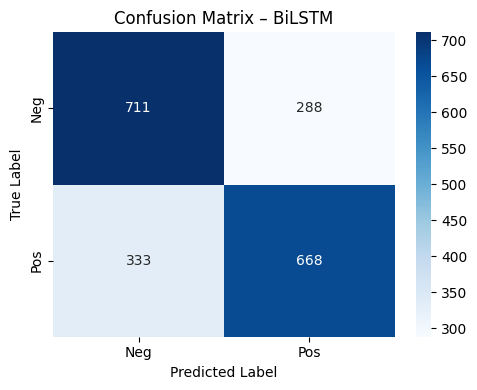


  BiLSTM — Yanlış Sınıflandırılan 5 Örnek

[1] True: Positive | Pred: Negative
    Text: If you want to see real evidence of what a misguided and unchecked government can do to "un-popular" people, this movie provides it. Read what some people are saying about the "Patriot Act" passed aft...

[2] True: Negative | Pred: Positive
    Text: Lucille Ball was a mighty power in television throughout the 1950s and 1960s, but she still made an occasional film, most notably THE LONG, LONG TRAILER and THE FACTS OF LIFE. Although her television ...

[3] True: Positive | Pred: Negative
    Text: Shtrafbat is the story only Russians could tell about the Second World War. The largest front of the whole conflict has been, ironically, the least appearing subject on the silver screen after the war...

[4] True: Negative | Pred: Positive
    Text: I was Stan in the movie "Dreams Come True". Stan was the friend that worked at the factory with the main character and ended getting his arm smashed in the m

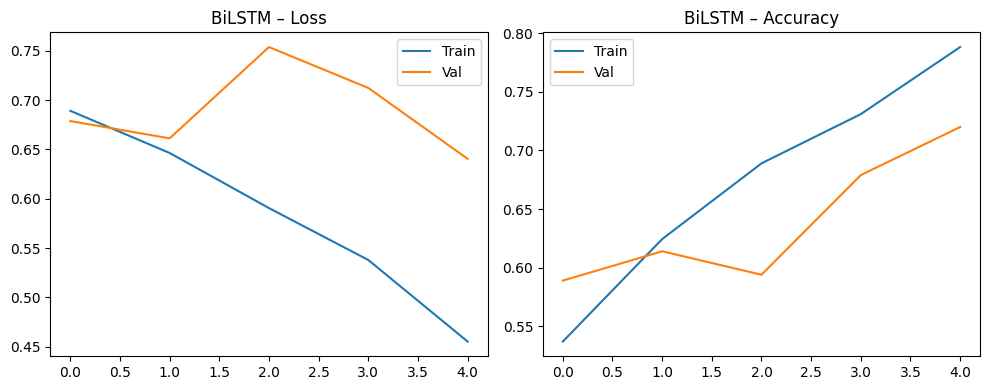

In [6]:
#Model 2: BiLSTM
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter

print("\n" + "█"*60)
print("  MODEL 2: BiLSTM")
print("█"*60)

# ── Vocabulary ───────────────────────────────────────────────────────────────
MAX_VOCAB = 20000
MAX_LEN   = 256    # token sayısı (truncation)
EMBED_DIM = 128
HIDDEN    = 256
DROPOUT   = 0.3
BATCH     = 64
EPOCHS_LSTM = 5
LR_LSTM   = 1e-3

def simple_tokenize(text):
    """Basit boşluk/noktalama tabanlı tokenizer."""
    import re
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return text.split()

# Vocab oluştur
print("Vocabulary oluşturuluyor...")
counter = Counter()
for text in X_train:
    counter.update(simple_tokenize(text))

vocab = {"<PAD>": 0, "<UNK>": 1}
for word, _ in counter.most_common(MAX_VOCAB - 2):
    vocab[word] = len(vocab)

print(f"Vocab boyutu: {len(vocab)}")


# ── Dataset ──────────────────────────────────────────────────────────────────
class IMDbDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts  = texts
        self.labels = labels
        self.vocab  = vocab
        self.max_len = max_len

    def encode(self, text):
        tokens = simple_tokenize(text)[:self.max_len]
        ids = [self.vocab.get(t, 1) for t in tokens]  # 1 = <UNK>
        # Padding
        ids += [0] * (self.max_len - len(ids))
        return torch.tensor(ids, dtype=torch.long)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.encode(self.texts[idx]), torch.tensor(self.labels[idx], dtype=torch.long)


train_ds = IMDbDataset(X_train, y_train, vocab, MAX_LEN)
val_ds   = IMDbDataset(X_val,   y_val,   vocab, MAX_LEN)
test_ds  = IMDbDataset(X_test,  y_test,  vocab, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH)
test_loader  = DataLoader(test_ds,  batch_size=BATCH)


# ── Model ────────────────────────────────────────────────────────────────────
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden, n_classes=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden, num_layers=2,
                            bidirectional=True, batch_first=True,
                            dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, n_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))       # (B, L, E)
        out, (hn, _) = self.lstm(emb)               # hn: (2*2, B, H)
        # Son iki katmanın forward/backward hidden state'ini al
        hidden = torch.cat([hn[-2], hn[-1]], dim=1) # (B, 2H)
        return self.fc(self.dropout(hidden))


bilstm = BiLSTM(len(vocab), EMBED_DIM, HIDDEN, dropout=DROPOUT).to(DEVICE)
optimizer_lstm = torch.optim.Adam(bilstm.parameters(), lr=LR_LSTM)
criterion = nn.CrossEntropyLoss()

print(f"\nBiLSTM parametreleri: {sum(p.numel() for p in bilstm.parameters()):,}")


# ── Eğitim Döngüsü ───────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss    += loss.item() * len(y_batch)
        total_correct += (logits.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_correct = 0, 0
    all_preds = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss    += loss.item() * len(y_batch)
            total_correct += (logits.argmax(1) == y_batch).sum().item()
            all_preds.extend(logits.argmax(1).cpu().numpy())
    return (total_loss / len(loader.dataset),
            total_correct / len(loader.dataset),
            all_preds)


history_lstm = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

print("\nBiLSTM eğitimi başlıyor...")
for epoch in range(1, EPOCHS_LSTM + 1):
    tr_loss, tr_acc = train_epoch(bilstm, train_loader, optimizer_lstm, criterion)
    vl_loss, vl_acc, _ = eval_epoch(bilstm, val_loader, criterion)

    history_lstm["train_acc"].append(tr_acc)
    history_lstm["val_acc"].append(vl_acc)
    history_lstm["train_loss"].append(tr_loss)
    history_lstm["val_loss"].append(vl_loss)

    print(f"Epoch {epoch}/{EPOCHS_LSTM} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

# Test
_, _, pred_lstm_test = eval_epoch(bilstm, test_loader, criterion)
acc_lstm, f1_lstm = evaluate(y_test, pred_lstm_test, "BiLSTM (TEST)")

plot_confusion_matrix(y_test, pred_lstm_test, "BiLSTM",
                      save_path="figures/q1_cm_bilstm.png")
show_misclassified(X_test, list(y_test), pred_lstm_test, n=5, model_name="BiLSTM")

# Eğitim eğrisi
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm["train_loss"], label="Train")
plt.plot(history_lstm["val_loss"],   label="Val")
plt.title("BiLSTM – Loss"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_lstm["train_acc"], label="Train")
plt.plot(history_lstm["val_acc"],   label="Val")
plt.title("BiLSTM – Accuracy"); plt.legend()
plt.tight_layout()
plt.savefig("figures/q1_bilstm_training.png", dpi=150)
plt.show()



████████████████████████████████████████████████████████████
  MODEL 3: DistilBERT
████████████████████████████████████████████████████████████


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DistilBERT tokenization yapılıyor (biraz sürer)...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT parametreleri: 66,955,010

DistilBERT eğitimi başlıyor...
Epoch 1/3 | Train Loss: 0.4887 Acc: 0.7542 | Val Loss: 0.3641 Acc: 0.8330
Epoch 2/3 | Train Loss: 0.2960 Acc: 0.8792 | Val Loss: 0.3572 Acc: 0.8500
Epoch 3/3 | Train Loss: 0.2028 Acc: 0.9286 | Val Loss: 0.3944 Acc: 0.8490

  DistilBERT (TEST)
  Accuracy  : 0.8660
  Macro-F1  : 0.8660
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86       999
    Positive       0.86      0.88      0.87      1001

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Kaydedildi: figures/q1_cm_bert.png


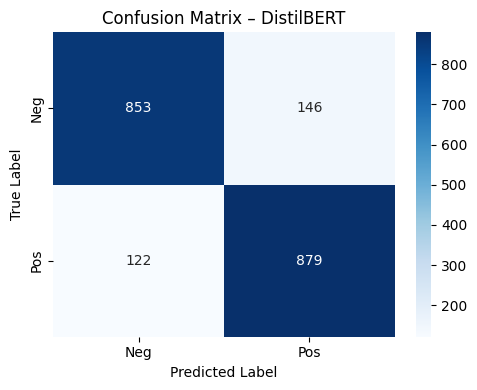


  DistilBERT — Yanlış Sınıflandırılan 5 Örnek

[1] True: Positive | Pred: Negative
    Text: I saw "Night of the Demons 2" first before I saw "Night of the Demons". Unfortunately, my old Blockbuster thought it was a good idea to have the sequel, but no first one. Looney, huh? Now, I think all...

[2] True: Negative | Pred: Positive
    Text: I've been a fan of Jim Henson and his characters since the very beginning. The most beguiling thing about them was the love and innocence and camaraderie shown. Kermit was a role model of deep thinkin...

[3] True: Positive | Pred: Negative
    Text: Shtrafbat is the story only Russians could tell about the Second World War. The largest front of the whole conflict has been, ironically, the least appearing subject on the silver screen after the war...

[4] True: Positive | Pred: Negative
    Text: Here's another Antonioni that will be rediscovered again and again as soon as it comes out on tape or DVD. I saw it a few months ago when it ran for the 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/CENG467/q1_distilbert/tokenizer_config.json',
 '/content/drive/MyDrive/CENG467/q1_distilbert/tokenizer.json')

In [7]:
# ════════════════════════════════════════════════════════════════════════════
# MODEL 3: DistilBERT Fine-Tuning
# ════════════════════════════════════════════════════════════════════════════
# GPU ZORUNLU. Colab Free'de ~20-30 dk sürer (5000 örnek, 3 epoch).

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           get_linear_schedule_with_warmup)

print("\n" + "█"*60)
print("  MODEL 3: DistilBERT")
print("█"*60)

BERT_MODEL  = "distilbert-base-uncased"
MAX_LEN_BERT = 128    # Colab Free için 128, Pro'da 256 yap
BATCH_BERT   = 32
EPOCHS_BERT  = 3
LR_BERT      = 2e-5

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)


# ── Dataset ──────────────────────────────────────────────────────────────────
class BertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx]
        }


print("DistilBERT tokenization yapılıyor (biraz sürer)...")
bert_train_ds = BertDataset(X_train, list(y_train), tokenizer, MAX_LEN_BERT)
bert_val_ds   = BertDataset(X_val,   list(y_val),   tokenizer, MAX_LEN_BERT)
bert_test_ds  = BertDataset(X_test,  list(y_test),  tokenizer, MAX_LEN_BERT)

bert_train_loader = DataLoader(bert_train_ds, batch_size=BATCH_BERT, shuffle=True)
bert_val_loader   = DataLoader(bert_val_ds,   batch_size=BATCH_BERT)
bert_test_loader  = DataLoader(bert_test_ds,  batch_size=BATCH_BERT)

# ── Model ────────────────────────────────────────────────────────────────────
bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=2
).to(DEVICE)

optimizer_bert = torch.optim.AdamW(bert_model.parameters(), lr=LR_BERT, weight_decay=0.01)
total_steps = len(bert_train_loader) * EPOCHS_BERT
scheduler = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f"DistilBERT parametreleri: {sum(p.numel() for p in bert_model.parameters()):,}")


# ── Eğitim ───────────────────────────────────────────────────────────────────
def bert_train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, total_correct = 0, 0
    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss    += loss.item() * len(labels)
        total_correct += (outputs.logits.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)


def bert_eval_epoch(model, loader):
    model.eval()
    total_loss, total_correct = 0, 0
    all_preds = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)
            total_loss    += outputs.loss.item() * len(labels)
            total_correct += (outputs.logits.argmax(1) == labels).sum().item()
            all_preds.extend(outputs.logits.argmax(1).cpu().numpy())
    return (total_loss / len(loader.dataset),
            total_correct / len(loader.dataset),
            all_preds)


history_bert = {"train_acc": [], "val_acc": []}

print("\nDistilBERT eğitimi başlıyor...")
for epoch in range(1, EPOCHS_BERT + 1):
    tr_loss, tr_acc = bert_train_epoch(bert_model, bert_train_loader,
                                        optimizer_bert, scheduler)
    vl_loss, vl_acc, _ = bert_eval_epoch(bert_model, bert_val_loader)

    history_bert["train_acc"].append(tr_acc)
    history_bert["val_acc"].append(vl_acc)

    print(f"Epoch {epoch}/{EPOCHS_BERT} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

# Test
_, _, pred_bert_test = bert_eval_epoch(bert_model, bert_test_loader)
acc_bert, f1_bert = evaluate(y_test, pred_bert_test, "DistilBERT (TEST)")

plot_confusion_matrix(y_test, pred_bert_test, "DistilBERT",
                      save_path="figures/q1_cm_bert.png")
show_misclassified(X_test, list(y_test), pred_bert_test, n=5, model_name="DistilBERT")

# ── Modeli Drive'a Kaydet ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
bert_model.save_pretrained("/content/drive/MyDrive/CENG467/q1_distilbert")
tokenizer.save_pretrained("/content/drive/MyDrive/CENG467/q1_distilbert")


═══════════════════════════════════════════════════════
  GENEL SONUÇLAR (Test Seti)
═══════════════════════════════════════════════════════
  Model                       Accuracy   Macro-F1
-------------------------------------------------------
  TF-IDF + LR               0.8725     0.8725
  BiLSTM                    0.6895     0.6894
  DistilBERT                0.8660     0.8660
═══════════════════════════════════════════════════════


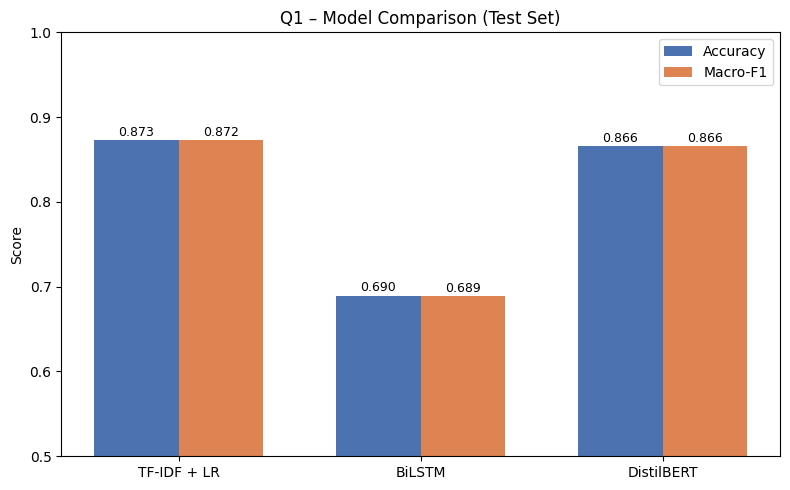


✅ Q1 tamamlandı! figures/ klasörüne bak.
   Sonuçları main.tex'teki Table 2'ye gir.


In [8]:
# ════════════════════════════════════════════════════════════════════════════
# HÜCRE 8 — Karşılaştırmalı Sonuç Tablosu
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "═"*55)
print("  GENEL SONUÇLAR (Test Seti)")
print("═"*55)
print(f"  {'Model':<25} {'Accuracy':>10} {'Macro-F1':>10}")
print("-"*55)
print(f"  {'TF-IDF + LR':<25} {acc_lr:.4f}     {f1_lr:.4f}")
print(f"  {'BiLSTM':<25} {acc_lstm:.4f}     {f1_lstm:.4f}")
print(f"  {'DistilBERT':<25} {acc_bert:.4f}     {f1_bert:.4f}")
print("═"*55)

# Bar chart
models  = ["TF-IDF + LR", "BiLSTM", "DistilBERT"]
acc_scores = [acc_lr, acc_lstm, acc_bert]
f1_scores  = [f1_lr,  f1_lstm,  f1_bert]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, acc_scores, width, label="Accuracy", color="#4C72B0")
bars2 = ax.bar(x + width/2, f1_scores,  width, label="Macro-F1", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Score")
ax.set_title("Q1 – Model Comparison (Test Set)")
ax.legend()
for bar in bars1 + bars2:
    ax.annotate(f"{bar.get_height():.3f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/q1_comparison.png", dpi=150)
plt.show()

print("\n✅ Q1 tamamlandı! figures/ klasörüne bak.")
print("   Sonuçları main.tex'teki Table 2'ye gir.")
